In [86]:
# ============================================================
# CELL 1 - IMPORT ALL LIBRARIES
# ============================================================
from pynq import Overlay, allocate
import numpy as np
import cv2
import time
from IPython.display import Image, display, clear_output
import ipywidgets as widgets
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")


✅ All libraries imported!


In [66]:
# ============================================================
# CELL 2 - LOAD BITSTREAM AND SETUP DMA
# ============================================================

# Load bitstream
ol = Overlay(
    "/home/xilinx/jupyter_notebooks/object_detection.bit"
)
print("✅ Overlay loaded!")
print("IPs found:")
for ip in ol.ip_dict:
    print(f"  → {ip}")

# Get DMA
dma = ol.axi_dma_0

# Image dimensions
IMG_W = 120
IMG_H = 120
SIZE  = IMG_W * IMG_H

in_buf  = allocate(shape=(SIZE,), dtype=np.uint8)
out_buf = allocate(shape=(SIZE,), dtype=np.uint8)

print(f"\n✅ DMA ready!")
print(f"Image size  : {IMG_W}x{IMG_H}")
print(f"Buffer size : {SIZE * 4} bytes")

✅ Overlay loaded!
IPs found:
  → axi_dma_0
  → axi_intc_0
  → processing_system7_0

✅ DMA ready!
Image size  : 120x120
Buffer size : 57600 bytes


In [42]:
def send_via_dma(frame):

    # Resize to FPGA expected size
    frame = cv2.resize(frame, (IMG_W, IMG_H))

    # 🔥 FIX: Convert to grayscale (IMPORTANT)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    frame_flat = frame.reshape(-1)

    # Safety check
    if frame_flat.size != in_buf.size:
        raise ValueError(
            f"DMA mismatch! frame={frame_flat.size}, buffer={in_buf.size}"
        )

    np.copyto(in_buf, frame_flat)

    dma.sendchannel.transfer(in_buf)
    dma.recvchannel.transfer(out_buf)
    dma.sendchannel.wait()
    dma.recvchannel.wait()

    # Return grayscale output
    return np.reshape(out_buf, (IMG_H, IMG_W))

In [4]:
# ============================================================
# CELL 4 - COLOR DETECTION SETUP
# ============================================================

# Define all color ranges in HSV
COLOR_RANGES = {
    "Red": (
        np.array([0,   120,  70]),
        np.array([10,  255, 255]),
        (0, 0, 255)
    ),
    "Red2": (
        np.array([170, 120,  70]),
        np.array([180, 255, 255]),
        (0, 0, 255)
    ),
    "Green": (
        np.array([36,  100,  70]),
        np.array([86,  255, 255]),
        (0, 255, 0)
    ),
    "Blue": (
        np.array([94,  100,  70]),
        np.array([126, 255, 255]),
        (255, 0, 0)
    ),
    "Yellow": (
        np.array([15,  100,  70]),
        np.array([35,  255, 255]),
        (0, 255, 255)
    ),
    "Orange": (
        np.array([11,  100,  70]),
        np.array([25,  255, 255]),
        (0, 165, 255)
    ),
    "Purple": (
        np.array([129, 100,  70]),
        np.array([158, 255, 255]),
        (255, 0, 255)
    ),
    "White": (
        np.array([0,    0,  200]),
        np.array([180,  30, 255]),
        (255, 255, 255)
    ),
    "Black": (
        np.array([0,    0,    0]),
        np.array([180, 255,  50]),
        (50, 50, 50)
    ),
}

def detect_colors(frame):
    """Detect all colors and draw bounding boxes"""
    hsv    = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    result = frame.copy()
    detected_colors = []
    kernel = np.ones((5,5), np.uint8)

    for color_name, (lower, upper, bgr) \
        in COLOR_RANGES.items():

        if color_name == "Red2":
            continue

        mask = cv2.inRange(hsv, lower, upper)

        # Combine both red ranges
        if color_name == "Red":
            lower2, upper2, _ = COLOR_RANGES["Red2"]
            mask2 = cv2.inRange(hsv, lower2, upper2)
            mask  = cv2.bitwise_or(mask, mask2)

        # Clean up mask
        mask = cv2.morphologyEx(
            mask, cv2.MORPH_OPEN,  kernel)
        mask = cv2.morphologyEx(
            mask, cv2.MORPH_CLOSE, kernel)

        # Find contours
        contours, _ = cv2.findContours(
            mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area > 1500:
                x,y,w,h = cv2.boundingRect(cnt)
                cx = x + w//2
                cy = y + h//2

                # Draw bounding box
                cv2.rectangle(
                    result,
                    (x,y), (x+w, y+h),
                    bgr, 3
                )

                # Draw center
                cv2.circle(
                    result, (cx,cy),
                    5, bgr, -1
                )

                # Draw label
                cv2.putText(
                    result,
                    f"{color_name}",
                    (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, bgr, 2
                )

                detected_colors.append({
                    "color": color_name,
                    "area":  area,
                    "pos":   (cx, cy)
                })

    return result, detected_colors


def get_color_percentage(frame):
    """Get percentage of each color in frame"""
    hsv   = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    total = frame.shape[0] * frame.shape[1]
    pcts  = {}

    for color_name, (lower, upper, bgr) \
        in COLOR_RANGES.items():

        if color_name == "Red2":
            continue

        mask = cv2.inRange(hsv, lower, upper)

        if color_name == "Red":
            lower2, upper2, _ = COLOR_RANGES["Red2"]
            mask2 = cv2.inRange(hsv, lower2, upper2)
            mask  = cv2.bitwise_or(mask, mask2)

        pct = (np.sum(mask > 0) / total) * 100
        if pct > 1.0:
            pcts[color_name] = round(pct, 2)

    return dict(sorted(
        pcts.items(),
        key=lambda x: x[1],
        reverse=True
    ))

print("✅ Color detection functions ready!")

✅ Color detection functions ready!


In [58]:
# ============================================================
# CELL 5 - OBJECT DETECTION SETUP (YOLO)
# ============================================================

# Load YOLO model
net = cv2.dnn.readNetFromDarknet(
    "yolov3-tiny.cfg",
    "yolov3-tiny.weights"
)
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

# Load class names
CLASSES = open("coco.names").read().strip().split("\n")
COLORS  = np.random.randint(
    0, 255,
    size=(len(CLASSES), 3),
    dtype=np.uint8
)

def detect_objects(frame):
    """Run YOLO object detection on frame"""
    H, W = frame.shape[:2]

    blob = cv2.dnn.blobFromImage(
        frame, 1/255.0,
        (320, 320),
        swapRB=True,
        crop=False
    )
    net.setInput(blob)
    outputs = net.forward(
        net.getUnconnectedOutLayersNames()
    )

    boxes, confs, ids = [], [], []

    for output in outputs:
        for det in output:
            scores = det[5:]
            cid    = np.argmax(scores)
            conf   = scores[cid]
            if conf > 0.5:
                cx,cy,w,h = \
                    (det[:4]*[W,H,W,H]).astype(int)
                boxes.append([cx-w//2,cy-h//2,w,h])
                confs.append(float(conf))
                ids.append(cid)

    idx   = cv2.dnn.NMSBoxes(
        boxes, confs, 0.5, 0.4)
    count = 0

    if len(idx) > 0:
        for i in idx.flatten():
            x,y,w,h  = boxes[i]
            color    = [int(c) for c in COLORS[ids[i]]]
            label    = f"{CLASSES[ids[i]]}: {confs[i]:.2f}"
            cv2.rectangle(
                frame,
                (x,y), (x+w,y+h),
                color, 2
            )
            cv2.putText(
                frame, label,
                (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, color, 2
            )
            count += 1

    return frame, count

print(f"✅ YOLO loaded! {len(CLASSES)} classes ready!")

✅ YOLO loaded! 80 classes ready!


In [6]:
import os

print(os.path.exists("/home/xilinx/yolov3-tiny.cfg"))
print(os.path.exists("/home/xilinx/yolov3-tiny.weights"))

False
False


In [7]:
import os

print(os.getcwd())

/home/xilinx/jupyter_notebooks


In [8]:
!ls


'Adaptive Noise cancellation.ipynb'	   speech_enhancement.ipynb
 base					   speech.wav
 Binary_transmission.ipynb		   Traffic_123
 cleaned_anc.wav			   Untitled10.ipynb
 cleaned.wav				   Untitled11.ipynb
 coco.names				   Untitled12.ipynb
 coco.names.txt				   Untitled13.ipynb
 common					   Untitled14.ipynb
 design_11.bit				   Untitled15.ipynb
 design_11_.bit				   Untitled16.ipynb
 design_11.hwh				   Untitled17.ipynb
 design12.hwh				   Untitled18.ipynb
 design_1.bit				   Untitled19.ipynb
 design_1.hwh				   Untitled1.ipynb
 design_1_wrapper.bit			   Untitled20.ipynb
 design_1_wrapper.hwh			   Untitled21.ipynb
 design_2_wrapper.bit			   Untitled22.ipynb
 design_2_wrapper.hwh			   Untitled23.ipynb
 design_3_wrapper.bit			   Untitled24.ipynb
 design_3_wrapper.hwh			   Untitled25.ipynb
 design.bit				   Untitled26.ipynb
 design.hwh				   Untitled27.ipynb
 Dolananda_SpeechEnhancement-Copy1.ipynb   Untitled2.ipynb
 Dolananda_SpeechEnhancement.ipynb	   Untitled3.ipynb
 Fir_filter				 

In [10]:
# ============================================================
# CELL 6 - EDGE DETECTION SETUP
# ============================================================

def detect_edges(frame,
                 low_thresh=50,
                 high_thresh=150):
    """
    Canny edge detection
    low_thresh  : lower threshold
    high_thresh : upper threshold
    """
    # Convert to grayscale
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur
    blur  = cv2.GaussianBlur(gray, (5,5), 0)

    # Canny edge detection
    edges = cv2.Canny(blur, low_thresh, high_thresh)

    # Convert back to BGR for display
    edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    # Color the edges green
    edges_colored        = np.zeros_like(frame)
    edges_colored[:,:,1] = edges

    # Overlay on original
    result = cv2.addWeighted(
        frame, 0.7,
        edges_colored, 0.3,
        0
    )

    edge_count = np.sum(edges > 0)
    return result, edges, edge_count


def detect_shapes(frame):
    """Detect shapes - circles, rectangles, triangles"""
    gray     = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur     = cv2.GaussianBlur(gray, (5,5), 0)
    edges    = cv2.Canny(blur, 50, 150)
    result   = frame.copy()
    contours,_ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    shapes_found = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 1000:
            continue

        peri    = cv2.arcLength(cnt, True)
        approx  = cv2.approxPolyDP(
            cnt, 0.04 * peri, True)
        x,y,w,h = cv2.boundingRect(approx)
        sides   = len(approx)

        if sides == 3:
            shape = "Triangle"
            color = (0, 255, 255)
        elif sides == 4:
            ratio = w / float(h)
            shape = "Square" \
                if 0.9 <= ratio <= 1.1 \
                else "Rectangle"
            color = (0, 255, 0)
        elif sides > 8:
            shape = "Circle"
            color = (255, 0, 0)
        else:
            shape = f"Polygon({sides})"
            color = (255, 255, 0)

        cv2.drawContours(
            result, [approx], -1, color, 2)
        cv2.putText(
            result, shape,
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6, color, 2
        )
        shapes_found.append(shape)

    return result, shapes_found

print("✅ Edge & Shape detection ready!")

✅ Edge & Shape detection ready!


In [12]:
# ============================================================
# CELL 7 - FACE AND EYE DETECTION SETUP
# ============================================================

# Load Haar cascades
face_cascade = cv2.CascadeClassifier(
    "/usr/share/opencv4/haarcascades/haarcascade_frontalface_default.xml"
)
eye_cascade = cv2.CascadeClassifier(
    "/usr/share/opencv4/haarcascades/haarcascade_eye.xml"
)

smile_cascade = cv2.CascadeClassifier(
    "/usr/share/opencv4/haarcascades/haarcascade_smile.xml"
)

def detect_faces(frame):
    """Detect faces eyes and smiles"""
    gray   = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    result = frame.copy()

    # Detect faces
    faces  = face_cascade.detectMultiScale(
        gray, 1.1, 5,
        minSize=(30,30)
    )

    face_count = 0

    for (x,y,w,h) in faces:
        face_count += 1

        # Draw face box
        cv2.rectangle(
            result,
            (x,y), (x+w,y+h),
            (0,255,0), 2
        )
        cv2.putText(
            result,
            f"Face {face_count}",
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6, (0,255,0), 2
        )

        # Detect eyes inside face
        roi_gray  = gray  [y:y+h, x:x+w]
        roi_color = result[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(
            roi_gray, 1.1, 3)

        for (ex,ey,ew,eh) in eyes:
            cv2.rectangle(
                roi_color,
                (ex,ey), (ex+ew,ey+eh),
                (255,0,0), 2
            )

        # Detect smile
        smiles = smile_cascade.detectMultiScale(
            roi_gray, 1.7, 20)

        for (sx,sy,sw,sh) in smiles:
            cv2.rectangle(
                roi_color,
                (sx,sy), (sx+sw,sy+sh),
                (0,0,255), 2
            )
            cv2.putText(
                roi_color, "Smile",
                (sx, sy-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0,0,255), 2
            )

    return result, face_count

print("✅ Face detection ready!")

✅ Face detection ready!


In [13]:
# ============================================================
# CELL 8 - MOTION DETECTION SETUP
# ============================================================

# Store previous frame
prev_frame = None

def detect_motion(frame, threshold=25):
    """Detect motion by comparing frames"""
    global prev_frame
    result = frame.copy()
    gray   = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray   = cv2.GaussianBlur(gray, (21,21), 0)

    if prev_frame is None:
        prev_frame = gray
        return result, False, 0

    # Frame difference
    diff       = cv2.absdiff(prev_frame, gray)
    thresh     = cv2.threshold(
        diff, threshold, 255,
        cv2.THRESH_BINARY
    )[1]

    # Dilate to fill gaps
    thresh = cv2.dilate(
        thresh,
        None,
        iterations=2
    )

    # Find motion contours
    contours,_ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    motion_detected = False
    motion_area     = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 500:
            motion_detected = True
            motion_area    += area
            x,y,w,h         = cv2.boundingRect(cnt)

            cv2.rectangle(
                result,
                (x,y), (x+w,y+h),
                (0,0,255), 2
            )
            cv2.putText(
                result, "MOTION",
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (0,0,255), 2
            )

    # Update previous frame
    prev_frame = gray

    # Add status
    status = "MOTION!" if motion_detected else "Still"
    color  = (0,0,255) if motion_detected else (0,255,0)
    cv2.putText(
        result, status,
        (10, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8, color, 2
    )

    return result, motion_detected, motion_area

print("✅ Motion detection ready!")

✅ Motion detection ready!


In [72]:
# ============================================================
# CELL 9 - COMBINED DETECTION RUNNER (FIXED VERSION)
# ============================================================

import time
import cv2
import numpy as np

MODE = "all"  # options: "color", "object", "edge", "face", "motion", "all"

# ---------------- CAMERA SETUP ----------------
cap = cv2.VideoCapture(0, cv2.CAP_V4L2)

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))

if not cap.isOpened():
    print("❌ Camera not found!")
else:
    print(f"✅ Camera opened! Mode: {MODE}")

# ---------------- LOOP SETUP ----------------
FRAMES = 30
fps_list = []

print(f"Running {FRAMES} frames in [{MODE}] mode")
print("=" * 50)

# ---------------- MAIN LOOP ----------------
for i in range(FRAMES):

    ret, frame = cap.read()
    if not ret:
        print("❌ Camera read failed!")
        break

    t1 = time.time()

    # ---------------- DMA CALL (FIXED) ----------------
    dma_frame = send_via_dma(frame)

    # Use original frame for detection
    result = frame.copy()
    info = {}

    # ---------------- DETECTIONS ----------------
    if MODE in ["color", "all"]:
        result, colors = detect_colors(result)
        pcts = get_color_percentage(result)
        info["colors"] = [c["color"] for c in colors]
        info["color_pct"] = pcts

    if MODE in ["object", "all"]:
        result, obj_count = detect_objects(result)
        info["objects"] = obj_count

    if MODE in ["edge", "all"]:
        result, edges, edge_count = detect_edges(result)
        info["edges"] = edge_count

    if MODE in ["face", "all"]:
        result, face_count = detect_faces(result)
        info["faces"] = face_count

    if MODE in ["motion", "all"]:
        result, moving, area = detect_motion(result)
        info["motion"] = moving
        info["motion_area"] = area

    # ---------------- FPS ----------------
    fps = 1.0 / (time.time() - t1)
    fps_list.append(fps)

    cv2.putText(
        result,
        f"FPS:{fps:.1f} Mode:{MODE}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )

    # ---------------- SAVE FRAME ----------------
    cv2.imwrite(f"result_{i}.jpg", result)

    # ---------------- LOGGING ----------------
    if i % 10 == 0:
        print(f"\nFrame {i:02d} | FPS: {fps:.1f}")
        for k, v in info.items():
            print(f"  {k:15}: {v}")

# ---------------- CLEANUP ----------------
cap.release()

try:
    in_buf.freebuffer()
    out_buf.freebuffer()
except:
    pass

print("\n" + "=" * 50)
print("✅ DONE!")

if fps_list:
    print(f"Average FPS : {np.mean(fps_list):.1f}")
    print(f"Best FPS    : {np.max(fps_list):.1f}")
else:
    print("No FPS data collected")

print("Frames saved: result_*.jpg")

✅ Camera opened! Mode: all
Running 30 frames in [all] mode

Frame 00 | FPS: 0.1
  colors         : ['Red', 'White', 'Black', 'Black', 'Black', 'Black', 'Black']
  color_pct      : {'White': 29.59, 'Red': 23.29, 'Black': 21.0}
  objects        : 0
  edges          : 11756
  faces          : 0
  motion         : True
  motion_area    : 241206.5

Frame 10 | FPS: 0.1
  colors         : ['Red', 'Red', 'White', 'Black', 'Black', 'Black', 'Black']
  color_pct      : {'Black': 26.23, 'Red': 14.8, 'White': 3.81}
  objects        : 0
  edges          : 10921
  faces          : 0
  motion         : True
  motion_area    : 26227.5


SystemError: <built-in function NMSBoxes> returned NULL without setting an error

In [49]:
!ls /dev/video*

/dev/video0  /dev/video1


In [50]:
import cv2

for i in [0, 1]:
    cap = cv2.VideoCapture(i, cv2.CAP_V4L2)
    print(f"Camera {i} opened:", cap.isOpened())
    ret, frame = cap.read()
    print(f"Camera {i} frame:", ret)
    cap.release()
    

Camera 0 opened: True
Camera 0 frame: True
Camera 1 opened: False
Camera 1 frame: False


Last captured frame:


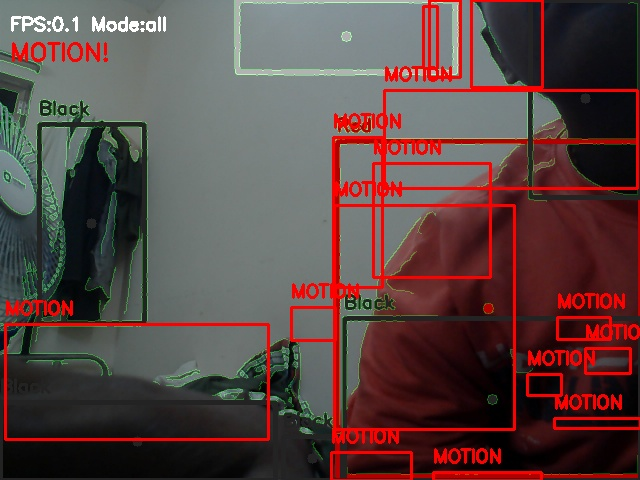

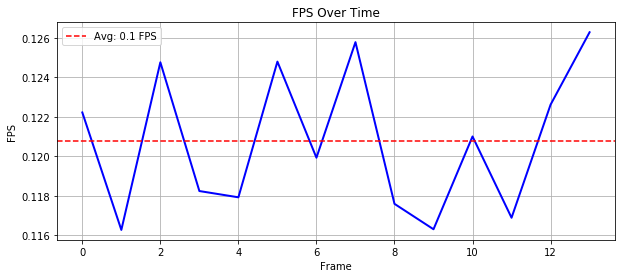

✅ Chart saved!


In [85]:
# ============================================================
# CELL 10 - SHOW RESULTS AND CHARTS
# ============================================================

import os

print("Last captured frame:")

if len(fps_list) > 0:
    last_idx = len(fps_list) - 1
    filename = f"result_{last_idx}.jpg"

    if os.path.exists(filename):
        display(Image(filename))
    else:
        print(f"⚠️ File not found: {filename}")
else:
    print("⚠️ No frames captured")
# Plot FPS chart
plt.figure(figsize=(10,4))
plt.plot(fps_list, color='blue', linewidth=2)
plt.axhline(
    y=np.mean(fps_list),
    color='red',
    linestyle='--',
    label=f'Avg: {np.mean(fps_list):.1f} FPS'
)
plt.title('FPS Over Time')
plt.xlabel('Frame')
plt.ylabel('FPS')
plt.legend()
plt.grid(True)
plt.savefig('/home/xilinx/fps_chart.png')
plt.show()
print("✅ Chart saved!")

In [84]:
# ============================================================
# CELL 11 - CLEANUP
# ============================================================
try:
    in_buf.freebuffer()
    out_buf.freebuffer()
    print("✅ Buffers freed!")
except:
    print("Buffers already freed")

print("✅ Done! Project complete!")

✅ Buffers freed!
✅ Done! Project complete!
